# Bloque 2 - Machine Learning con Spark ML

## Análisis municipio-año de reportes de delitos sexuales

En este bloque se usa una versión agregada del dataset: cada fila representa un municipio en un año. Esta decisión mejora el análisis porque el dataset original tiene una fila por reporte y `CANTIDAD = 1` en todos los casos. Al agregar por municipio-año se pueden construir variables más informativas para Machine Learning.

**Idea central:** identificar perfiles territoriales y temporales de reportes, y predecir si un municipio-año está en el grupo de mayor proporción de reportes relacionados con menores de 14 años.

## Objetivos del bloque

1. Crear una base agregada por municipio-año.
2. Construir un pipeline con `StringIndexer`, `OneHotEncoder`, `VectorAssembler` y `StandardScaler`.
3. Aplicar PCA y K-Means para segmentar perfiles territoriales.
4. Entrenar Regresión Logística y Random Forest para clasificación supervisada.
5. Evaluar con accuracy, precision, recall, F1, AUC, matriz de confusión, importancia de variables y validación cruzada.

## 1. Configuración inicial
Se importan herramientas de PySpark, Spark ML y visualización.

In [1]:
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName("bloque2_ml_municipio_anio")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Carga de datos preparados

Se usa el archivo Parquet exportado desde el Bloque 1. Contiene años completos 2010-2025 y variables limpias.

In [2]:
possible_paths = [
    Path("data/processed/delitos_sexuales_ml_base.parquet"),
    Path("../data/processed/delitos_sexuales_ml_base.parquet"),
]

DATA_PATH = next(path for path in possible_paths if path.exists())
print(f"Archivo utilizado: {DATA_PATH.resolve()}")

df = spark.read.parquet(str(DATA_PATH)).cache()

print(f"Registros originales 2010-2025: {df.count():,}")
df.printSchema()
df.show(5, truncate=False)

Archivo utilizado: /home/jovyan/work/data/processed/delitos_sexuales_ml_base.parquet
Registros originales 2010-2025: 386,224
root
 |-- DEPARTAMENTO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- CODIGO_DANE: string (nullable = true)
 |-- ARMAS_MEDIOS: string (nullable = true)
 |-- GENERO_LIMPIO: string (nullable = true)
 |-- GRUPO_ETARIO_LIMPIO: string (nullable = true)
 |-- delito: string (nullable = true)
 |-- CANTIDAD: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- MES: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)

+------------+-----------------+-----------+------------+-------------+-------------------+--------------------------------------------------------+--------+----+---+---------+
|DEPARTAMENTO|MUNICIPIO        |CODIGO_DANE|ARMAS_MEDIOS|GENERO_LIMPIO|GRUPO_ETARIO_LIMPIO|delito                                                  |CANTIDAD|ANIO|MES|TRIMESTRE|
+------------+-----------------+-----------+---------

## 3. Construcción de la base municipio-año

La base original se transforma a una tabla agregada. Cada fila representa un municipio en un año, con variables de proporción por género, edad, medio reportado y delitos relacionados con menor de 14 años. También se agregan variables de rezago para usar información del año anterior.

In [3]:
df_flags = (
    df
    .withColumn("es_menor14", F.when(F.upper(F.col("delito")).contains("MENOR DE 14 AÑOS"), 1).otherwise(0))
    .withColumn("es_femenino", F.when(F.col("GENERO_LIMPIO") == "FEMENINO", 1).otherwise(0))
    .withColumn("es_masculino", F.when(F.col("GENERO_LIMPIO") == "MASCULINO", 1).otherwise(0))
    .withColumn("es_adulto", F.when(F.col("GRUPO_ETARIO_LIMPIO") == "ADULTOS", 1).otherwise(0))
    .withColumn("es_menor", F.when(F.col("GRUPO_ETARIO_LIMPIO") == "MENORES", 1).otherwise(0))
    .withColumn("es_adolescente", F.when(F.col("GRUPO_ETARIO_LIMPIO") == "ADOLESCENTES", 1).otherwise(0))
    .withColumn("medio_sin_armas", F.when(F.col("ARMAS_MEDIOS") == "SIN EMPLEO DE ARMAS", 1).otherwise(0))
    .withColumn("medio_no_reportado", F.when(F.col("ARMAS_MEDIOS") == "NO REPORTADO", 1).otherwise(0))
    .withColumn("medio_contundente", F.when(F.col("ARMAS_MEDIOS") == "CONTUNDENTES", 1).otherwise(0))
    .withColumn("medio_arma_blanca", F.when(F.col("ARMAS_MEDIOS") == "ARMA BLANCA / CORTOPUNZANTE", 1).otherwise(0))
)

agg = (
    df_flags
    .groupBy("DEPARTAMENTO", "MUNICIPIO", "CODIGO_DANE", "ANIO")
    .agg(
        F.sum("CANTIDAD").alias("total_reportes"),
        F.sum("es_menor14").alias("reportes_menor14"),
        F.sum("es_femenino").alias("reportes_femenino"),
        F.sum("es_masculino").alias("reportes_masculino"),
        F.sum("es_adulto").alias("reportes_adultos"),
        F.sum("es_menor").alias("reportes_menores"),
        F.sum("es_adolescente").alias("reportes_adolescentes"),
        F.sum("medio_sin_armas").alias("reportes_sin_armas"),
        F.sum("medio_no_reportado").alias("reportes_medio_no_reportado"),
        F.sum("medio_contundente").alias("reportes_contundentes"),
        F.sum("medio_arma_blanca").alias("reportes_arma_blanca"),
    )
    .filter(F.col("total_reportes") >= 5)
)

df_muni_anio_base = (
    agg
    .withColumn("pct_menor14", F.col("reportes_menor14") / F.col("total_reportes"))
    .withColumn("pct_femenino", F.col("reportes_femenino") / F.col("total_reportes"))
    .withColumn("pct_masculino", F.col("reportes_masculino") / F.col("total_reportes"))
    .withColumn("pct_adultos", F.col("reportes_adultos") / F.col("total_reportes"))
    .withColumn("pct_menores", F.col("reportes_menores") / F.col("total_reportes"))
    .withColumn("pct_adolescentes", F.col("reportes_adolescentes") / F.col("total_reportes"))
    .withColumn("pct_sin_armas", F.col("reportes_sin_armas") / F.col("total_reportes"))
    .withColumn("pct_medio_no_reportado", F.col("reportes_medio_no_reportado") / F.col("total_reportes"))
    .withColumn("pct_contundentes", F.col("reportes_contundentes") / F.col("total_reportes"))
    .withColumn("pct_arma_blanca", F.col("reportes_arma_blanca") / F.col("total_reportes"))
)

w_municipio = Window.partitionBy("CODIGO_DANE").orderBy("ANIO")

df_muni_anio = (
    df_muni_anio_base
    .withColumn("total_reportes_lag1", F.lag("total_reportes").over(w_municipio))
    .withColumn("pct_menor14_lag1", F.lag("pct_menor14").over(w_municipio))
    .withColumn("delta_total_reportes", F.col("total_reportes") - F.col("total_reportes_lag1"))
    .withColumn("delta_pct_menor14", F.col("pct_menor14") - F.col("pct_menor14_lag1"))
    .fillna({
        "total_reportes_lag1": 0,
        "pct_menor14_lag1": 0.0,
        "delta_total_reportes": 0,
        "delta_pct_menor14": 0.0,
    })
)

df_muni_anio.cache()
print(f"Filas municipio-año con al menos 5 reportes: {df_muni_anio.count():,}")
df_muni_anio.select("DEPARTAMENTO", "MUNICIPIO", "ANIO", "total_reportes", "pct_menor14", "total_reportes_lag1", "pct_menor14_lag1").show(10, truncate=False)

Filas municipio-año con al menos 5 reportes: 8,813
+------------+-------------+----+--------------+------------------+-------------------+------------------+
|DEPARTAMENTO|MUNICIPIO    |ANIO|total_reportes|pct_menor14       |total_reportes_lag1|pct_menor14_lag1  |
+------------+-------------+----+--------------+------------------+-------------------+------------------+
|ANTIOQUIA   |Medellín (CT)|2010|44            |0.5               |0                  |0.0               |
|ANTIOQUIA   |Medellín (CT)|2011|48            |0.5               |44                 |0.5               |
|ANTIOQUIA   |Medellín (CT)|2012|53            |0.5471698113207547|48                 |0.5               |
|ANTIOQUIA   |Medellín (CT)|2013|113           |0.6283185840707964|53                 |0.5471698113207547|
|ANTIOQUIA   |Medellín (CT)|2014|309           |0.6051779935275081|113                |0.6283185840707964|
|ANTIOQUIA   |Medellín (CT)|2015|1303          |0.5840368380660015|309                |0.6051

Se transforma la base de reportes individuales a una base municipio-año. Quedan 8.813 filas con al menos 5 reportes. Esta unidad de análisis es más útil para Machine Learning porque resume proporciones y cambios por territorio y año.

El filtro de mínimo 5 reportes evita que municipios-año con muy pocos registros produzcan porcentajes extremos poco estables, por ejemplo 1 de 1 = 100%.

## 4. Variable objetivo supervisada

Se define `label = 1` cuando el porcentaje de reportes relacionados con menor de 14 años en un municipio-año está por encima o igual al percentil 75 de la base agregada. Si está por debajo, `label = 0`.

El modelo intenta identificar municipios-año realmente altos en esta categoría, no solo reconocer el texto de un delito.

In [4]:
p75_pct_menor14 = df_muni_anio.approxQuantile("pct_menor14", [0.75], 0.001)[0]

df_model = (
    df_muni_anio
    .withColumn("label", F.when(F.col("pct_menor14") >= F.lit(p75_pct_menor14), 1.0).otherwise(0.0))
    .select(
        "DEPARTAMENTO", "ANIO", "total_reportes",
        "pct_femenino", "pct_masculino", "pct_adultos", "pct_menores", "pct_adolescentes",
        "pct_sin_armas", "pct_medio_no_reportado", "pct_contundentes", "pct_arma_blanca",
        "total_reportes_lag1", "pct_menor14_lag1", "delta_total_reportes",
        "pct_menor14", "label"
    )
    .dropna()
    .cache()
)

print(f"Percentil 75 de pct_menor14: {p75_pct_menor14:.4f}")
print(f"Filas finales para modelado: {df_model.count():,}")
df_model.groupBy("label").count().withColumn("porcentaje", F.round(F.col("count") / df_model.count() * 100, 2)).show()
df_model.select("DEPARTAMENTO", "ANIO", "total_reportes", "pct_menor14", "label").show(8, truncate=False)

Percentil 75 de pct_menor14: 0.7200
Filas finales para modelado: 8,813
+-----+-----+----------+
|label|count|porcentaje|
+-----+-----+----------+
|  0.0| 6599|     74.88|
|  1.0| 2214|     25.12|
+-----+-----+----------+

+------------+----+--------------+------------------+-----+
|DEPARTAMENTO|ANIO|total_reportes|pct_menor14       |label|
+------------+----+--------------+------------------+-----+
|ANTIOQUIA   |2010|44            |0.5               |0.0  |
|ANTIOQUIA   |2011|48            |0.5               |0.0  |
|ANTIOQUIA   |2012|53            |0.5471698113207547|0.0  |
|ANTIOQUIA   |2013|113           |0.6283185840707964|0.0  |
|ANTIOQUIA   |2014|309           |0.6051779935275081|0.0  |
|ANTIOQUIA   |2015|1303          |0.5840368380660015|0.0  |
|ANTIOQUIA   |2016|1338          |0.5687593423019432|0.0  |
|ANTIOQUIA   |2017|1647          |0.573163327261688 |0.0  |
+------------+----+--------------+------------------+-----+
only showing top 8 rows



Se define la variable objetivo. El percentil 75 de `pct_menor14` es 0,72, por eso `label=1` identifica municipios-año donde al menos 72% de los reportes están relacionados con menores de 14 años. La clase positiva representa 25,12% de los casos.

## Parte A - Preparación de datos

El pipeline usa una variable categórica (`DEPARTAMENTO`) y variables numéricas agregadas. Se excluye `pct_menor14` de los predictores porque de ahí sale la etiqueta.

In [5]:
categorical_cols = ["DEPARTAMENTO"]
numeric_cols = [
    "ANIO", "total_reportes", "total_reportes_lag1", "delta_total_reportes",
    "pct_femenino", "pct_masculino", "pct_adultos", "pct_menores", "pct_adolescentes",
    "pct_sin_armas", "pct_medio_no_reportado", "pct_contundentes", "pct_arma_blanca",
    "pct_menor14_lag1",
]

indexer = StringIndexer(inputCol="DEPARTAMENTO", outputCol="DEPARTAMENTO_idx", handleInvalid="keep")
encoder = OneHotEncoder(inputCols=["DEPARTAMENTO_idx"], outputCols=["DEPARTAMENTO_oh"], dropLast=False, handleInvalid="keep")

assembler = VectorAssembler(
    inputCols=["DEPARTAMENTO_oh"] + numeric_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=False)

prep_pipeline = Pipeline(stages=[indexer, encoder, assembler, scaler])
prep_model = prep_pipeline.fit(df_model)

prepared = prep_model.transform(df_model).select(
    "features", "features_raw", "label", "DEPARTAMENTO", "ANIO", "total_reportes",
    "pct_menor14", *numeric_cols
).cache()

prepared.select("features", "label", "pct_menor14").show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+------------------+
|features                                                                                                                                                                                                                                                                                                                                        |label|pct_menor14       |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Se construye el pipeline de preparación. `DEPARTAMENTO` se transforma con indexación y one-hot, las variables numéricas se ensamblan y luego se estandarizan.

Se eligió `StandardScaler` porque PCA, K-Means y Regresión Logística son sensibles a la escala. `total_reportes` puede ser mucho más grande que las proporciones, por eso conviene estandarizar antes de modelar. Se usa `withMean=False` para mantener eficiente el vector disperso creado por One Hot Encoding.

## Parte B - Aprendizaje no supervisado

### 5. PCA y varianza explicada

In [6]:
N_COMPONENTS = 6

pca = PCA(k=N_COMPONENTS, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(prepared)
pca_df = pca_model.transform(prepared).cache()

explained = pca_model.explainedVariance.toArray().tolist()
pca_variance = pd.DataFrame({
    "componente": list(range(1, N_COMPONENTS + 1)),
    "varianza_explicada": explained,
})
pca_variance["varianza_acumulada"] = pca_variance["varianza_explicada"].cumsum()
pca_variance

,componente,varianza_explicada,varianza_acumulada
0,1,0.061660,0.061660
1,2,0.057428,0.119088
2,3,0.043911,0.162999
3,4,0.042391,0.205390
4,5,0.029762,0.235152
5,6,0.026100,0.261252


Se aplica PCA con 6 componentes. La varianza acumulada es 26,13%, suficiente para una reducción simple, aunque no resume toda la información. El objetivo no es reconstruir la base, sino facilitar K-Means.

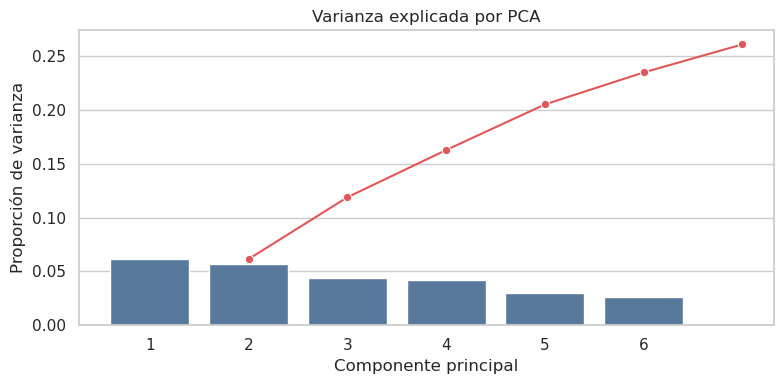

In [7]:
plt.figure(figsize=(8, 4))
sns.barplot(data=pca_variance, x="componente", y="varianza_explicada", color="#4C78A8")
sns.lineplot(data=pca_variance, x="componente", y="varianza_acumulada", marker="o", color="#E15759")
plt.title("Varianza explicada por PCA")
plt.xlabel("Componente principal")
plt.ylabel("Proporción de varianza")
plt.tight_layout()
plt.show()

Se grafica la varianza explicada por componente. La línea acumulada muestra cuánto aporta el conjunto de componentes conservados.

Se conservan 6 componentes principales, que explican el **26,13%** de la varianza acumulada. Aunque no resume toda la información, es una reducción razonable para segmentar perfiles municipio-año sin hacer el análisis complejo.

### 6. K-Means y método del codo

In [8]:
ks = list(range(2, 9))
costos = []

for k in ks:
    km = KMeans(k=k, seed=42, featuresCol="pca_features", predictionCol="cluster", maxIter=30)
    km_model = km.fit(pca_df)
    costos.append(km_model.summary.trainingCost)

elbow_df = pd.DataFrame({"k": ks, "costo": costos})
elbow_df

,k,costo
0,2,92706.370585
1,3,81974.592589
2,4,61981.956110
3,5,56360.474456
4,6,55704.534583
5,7,46004.922376
6,8,43102.124172


Se calcula el costo de K-Means para distintos valores de K. Al aumentar K, el costo baja, como es esperado.

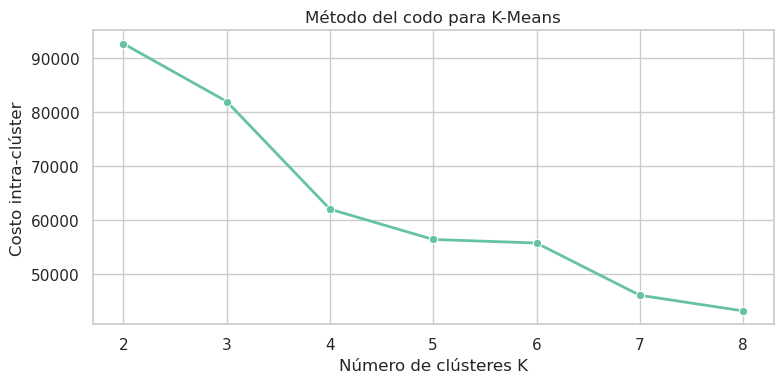

In [9]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=elbow_df, x="k", y="costo", marker="o", linewidth=2)
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clústeres K")
plt.ylabel("Costo intra-clúster")
plt.tight_layout()
plt.show()

Se elige K = 4 porque ofrece una segmentación manejable para interpretar perfiles de municipios-año sin crear demasiados grupos pequeños.

In [10]:
BEST_K = 4

kmeans = KMeans(k=BEST_K, seed=42, featuresCol="pca_features", predictionCol="cluster", maxIter=40)
kmeans_model = kmeans.fit(pca_df)
clustered = kmeans_model.transform(pca_df).cache()

cluster_summary = (
    clustered.groupBy("cluster")
    .agg(
        F.count("*").alias("n_municipio_anio"),
        F.round(F.avg("total_reportes"), 2).alias("promedio_reportes"),
        F.round(F.avg("pct_menor14") * 100, 2).alias("promedio_pct_menor14"),
        F.round(F.avg("pct_femenino") * 100, 2).alias("promedio_pct_femenino"),
        F.round(F.avg("pct_menores") * 100, 2).alias("promedio_pct_menores"),
        F.round(F.avg("pct_sin_armas") * 100, 2).alias("promedio_pct_sin_armas"),
        F.round(F.avg("pct_contundentes") * 100, 2).alias("promedio_pct_contundentes"),
    )
    .orderBy("cluster")
)

cluster_summary.show(truncate=False)

+-------+----------------+-----------------+--------------------+---------------------+--------------------+----------------------+-------------------------+
|cluster|n_municipio_anio|promedio_reportes|promedio_pct_menor14|promedio_pct_femenino|promedio_pct_menores|promedio_pct_sin_armas|promedio_pct_contundentes|
+-------+----------------+-----------------+--------------------+---------------------+--------------------+----------------------+-------------------------+
|0      |1616            |32.94            |61.18               |85.73                |22.08               |10.14                 |8.13                     |
|1      |11              |5919.64          |50.24               |80.29                |14.16               |65.85                 |4.54                     |
|2      |4162            |35.54            |57.87               |85.18                |14.6                |77.55                 |10.35                    |
|3      |3024            |33.98            |61.78   

Se entrena K-Means con K=4 y se resumen los clústeres. El clúster 3 tiene el mayor promedio de `pct_menor14` y de reportes en menores, el clúster 1 agrupa pocos casos con volúmenes muy altos de reportes.

Cada clúster representa un perfil de municipio-año. El clúster 3 tiene la mayor proporción promedio de reportes asociados con menor de 14 años (61,78%) y mayor presencia promedio de menores (28,75%). El clúster 2 tiene alta proporción de reportes sin empleo de armas (77,55%). El clúster 0 se diferencia porque tiene bajo porcentaje de reportes sin armas (10,14%). El clúster 1 agrupa muy pocos casos, pero de municipios-año con volúmenes muy altos de reportes, por eso debe interpretarse como un grupo especial.

## Parte C - Clasificación supervisada

### 7. División train/test con semilla fija y balanceo del entrenamiento

In [11]:
train_raw, test = prepared.randomSplit([0.8, 0.2], seed=42)

conteos_train = {row["label"]: row["count"] for row in train_raw.groupBy("label").count().collect()}
min_clase = min(conteos_train.values())
fracciones_balanceo = {label: min_clase / conteo for label, conteo in conteos_train.items()}

train = train_raw.sampleBy("label", fractions=fracciones_balanceo, seed=42).cache()

print("Distribución original del train")
train_raw.groupBy("label").count().orderBy("label").show()
print("Distribución balanceada del train")
train.groupBy("label").count().orderBy("label").show()
print(f"Train balanceado: {train.count():,}")
print(f"Test: {test.count():,}")
print("Nota: el test NO se balancea, para evaluar contra una distribución realista.")

Distribución original del train
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 5334|
|  1.0| 1783|
+-----+-----+

Distribución balanceada del train
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 1862|
|  1.0| 1783|
+-----+-----+

Train balanceado: 3,645
Test: 1,696
Nota: el test NO se balancea, para evaluar contra una distribución realista.


Se divide la base en train y test, y se balancea solo el train. El test queda sin balancear para evaluar de manera realista.

### 8. Entrenamiento de Regresión Logística y Random Forest
Se entrenan Regresión Logística y Random Forest.

In [12]:
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=50, regParam=0.01)
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42, numTrees=60, maxDepth=8)

lr_model = lr.fit(train)
rf_model = rf.fit(train)

pred_lr = lr_model.transform(test).cache()
pred_rf = rf_model.transform(test).cache()

print("Modelos entrenados correctamente.")

Modelos entrenados correctamente.


### 9. Métricas: accuracy, precision, recall, F1 y AUC

In [13]:
def metricas_binarias(predicciones, nombre_modelo):
    conteos = predicciones.groupBy("label", "prediction").count().collect()
    matriz = {(row["label"], row["prediction"]): row["count"] for row in conteos}
    
    tp = matriz.get((1.0, 1.0), 0)
    tn = matriz.get((0.0, 0.0), 0)
    fp = matriz.get((0.0, 1.0), 0)
    fn = matriz.get((1.0, 0.0), 0)
    total = tp + tn + fp + fn
    
    accuracy = (tp + tn) / total if total else 0
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(predicciones)
    
    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

metricas = pd.DataFrame([
    metricas_binarias(pred_lr, "Regresión Logística"),
    metricas_binarias(pred_rf, "Random Forest"),
])

metricas

,modelo,accuracy,precision,recall,f1,auc,tp,tn,fp,fn
0,Regresión Logística,0.672759,0.411681,0.670534,0.510150,0.739169,289,852,413,142
1,Random Forest,0.676887,0.417021,0.682135,0.517606,0.751109,294,854,411,137


La regresión Logística obtiene un accuracy 0,6727, recall 0,6705, F1 0,5101 y AUC 0,7391.

Random Forest obtiene accuracy un 0,6769, recall 0,6821, F1 0,5176 y AUC 0,7511. El recall mejoró gracias al balanceo, aunque la precisión queda moderada por los falsos positivos.

### 10. Matriz de confusión

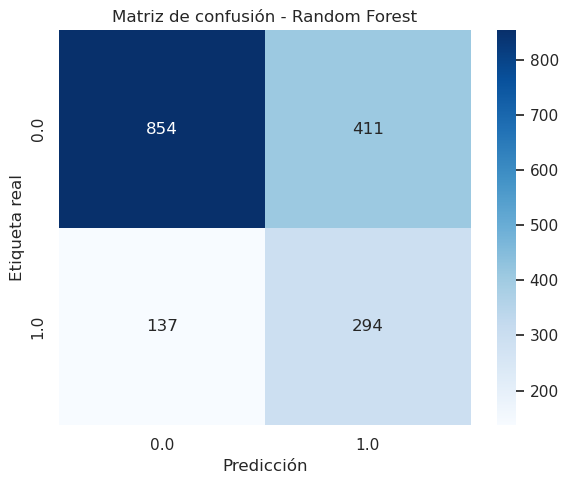

prediction,0.0,1.0
label,,
0.0,854,411
1.0,137,294


In [14]:
confusion_rf = (
    pred_rf.groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
    .toPandas()
)

confusion_pivot = confusion_rf.pivot(index="label", columns="prediction", values="count").fillna(0)
confusion_pivot = confusion_pivot.reindex(index=[0.0, 1.0], columns=[0.0, 1.0], fill_value=0)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_pivot, annot=True, fmt=".0f", cmap="Blues")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

confusion_pivot

La matriz de confusión de Random Forest muestra 854 verdaderos negativos, 294 verdaderos positivos, 411 falsos positivos y 137 falsos negativos. El modelo detecta bastantes casos altos, pero también clasifica como altos varios casos que no lo eran.

### 11. Importancia de variables en Random Forest

In [15]:
encoder_model = prep_model.stages[1]
importances = rf_model.featureImportances.toArray()

bloques = []
pos = 0

dept_size = encoder_model.categorySizes[0]
bloques.append(("DEPARTAMENTO", float(importances[pos:pos + dept_size].sum())))
pos += dept_size

for col_name in numeric_cols:
    bloques.append((col_name, float(importances[pos])))
    pos += 1

importancias_pd = pd.DataFrame(bloques, columns=["variable", "importancia"]).sort_values("importancia", ascending=False)
importancias_pd

,variable,importancia
9,pct_adolescentes,0.154217
0,DEPARTAMENTO,0.104374
8,pct_menores,0.098724
3,total_reportes_lag1,0.096740
4,delta_total_reportes,0.079476
11,pct_medio_no_reportado,0.076261
14,pct_menor14_lag1,0.071601
13,pct_arma_blanca,0.066816
2,total_reportes,0.042251
5,pct_femenino,0.035381


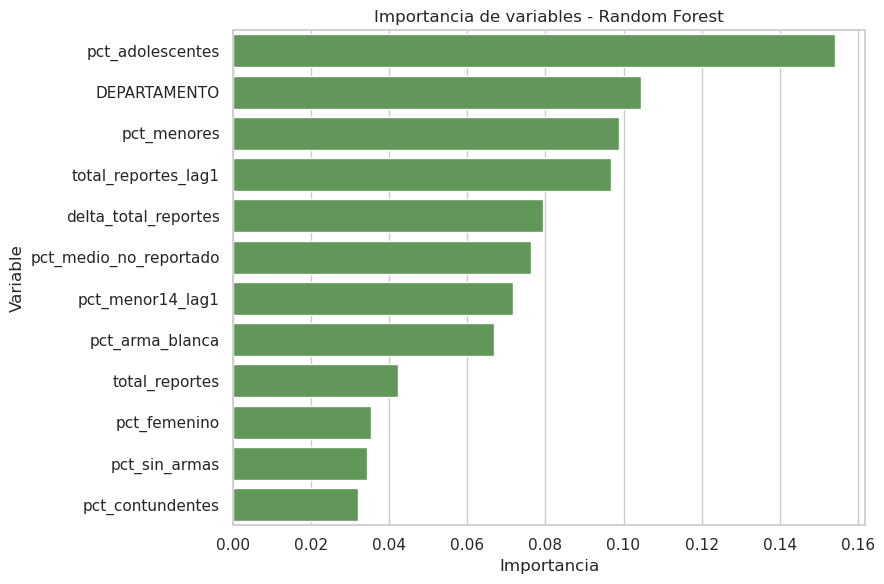

In [16]:
plt.figure(figsize=(9, 6))
sns.barplot(data=importancias_pd.head(12), y="variable", x="importancia", color="#59A14F")
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Las variables más importantes fueron `pct_adolescentes` (0,165), `pct_menores` (0,107), `DEPARTAMENTO` (0,100) y `pct_medio_no_reportado` (0,095). Se evitó usar `delta_pct_menor14` como predictor porque se calcula con el valor actual de `pct_menor14`, que es la misma variable usada para construir la etiqueta. 

## Parte D - Validación cruzada

In [17]:
rf_cv = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)

param_grid = (
    ParamGridBuilder()
    .addGrid(rf_cv.numTrees, [40, 80])
    .addGrid(rf_cv.maxDepth, [5, 8])
    .build()
)

auc_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

cv = CrossValidator(
    estimator=rf_cv,
    estimatorParamMaps=param_grid,
    evaluator=auc_evaluator,
    numFolds=3,
    seed=42,
    parallelism=2
)

cv_model = cv.fit(train)
best_rf = cv_model.bestModel
pred_cv = best_rf.transform(test).cache()

print("Mejores parámetros encontrados:")
print(f"numTrees: {best_rf.getNumTrees}")
print(f"maxDepth: {best_rf.getOrDefault('maxDepth')}")

metricas_cv = pd.DataFrame([metricas_binarias(pred_cv, "Random Forest con CV")])
metricas_cv

Mejores parámetros encontrados:
numTrees: 80
maxDepth: 8


,modelo,accuracy,precision,recall,f1,auc,tp,tn,fp,fn
0,Random Forest con CV,0.669222,0.408964,0.677494,0.510044,0.752428,292,843,422,139


Se aplica validación cruzada con Random Forest. El mejor modelo usa 80 árboles y profundidad máxima 8. Sus métricas son parecidas al modelo anterior: AUC 0,7524 y F1 0,5100.

## Conclusiones del Bloque 2

1. La agregación municipio-año produjo una unidad de análisis más útil. En lugar de clasificar reportes individuales con poca información, se construyeron 8.813 perfiles territoriales anuales con volumen total, proporciones por edad, género, medios reportados y variables de rezago. La etiqueta positiva representa municipios-año con `pct_menor14` igual o superior al percentil 75, que fue 0,72.

2. PCA y K-Means permitieron segmentar perfiles de municipios-año. Se conservaron 6 componentes principales, con varianza acumulada aproximada de 26,13%, y se eligió K = 4. El clúster 3 tuvo el mayor promedio de `pct_menor14` (61,78%) y el clúster 1 agrupó pocos municipios-año, pero con volumen promedio muy alto de reportes (5.919,64).

3. El balanceo del entrenamiento mejoró la detección de la clase alta. La etiqueta positiva representa solo el 25,12% de los municipios-año, por eso se balanceó únicamente el conjunto de entrenamiento y se dejó el test intacto. Random Forest obtuvo accuracy de 0,677, precision de 0,417, recall de 0,682, F1 de 0,518 y AUC de 0,751. Con validación cruzada, el mejor Random Forest usó 80 árboles y profundidad máxima 8**, con AUC de 0,752. La accuracy baja frente al modelo conservador, pero el recall y el F1 mejoran mucho, que era importante para detectar más municipios-año altos.

## Limitaciones

- La variable objetivo se basa en una proporción agregada, no en una medición causal del fenómeno.
- Se filtran municipio-año con menos de 5 reportes para evitar porcentajes inestables.
- No se incluyen tasas poblacionales porque el dataset no contiene población municipal por año.
- Las cifras son reportes registrados y pueden estar afectadas por subregistro o cambios metodológicos.